# Análisis Exploratorio - Logistica

**Objetivo:** Validación, exploración y limpieza del dataset de supply chain.

**Alcance:**
- Validación de datos (shape, tipos, nulos, duplicados, fechas)
- EDA con visualizaciones (target, delivery status, shipping mode, markets, temporal)
- Feature engineering exploratorio (processing_time)
- Limpieza y eliminación de columnas irrelevantes/sensibles
- Guardado de dataset limpio

**No incluye:** Machine learning, codificación de variables, splits, ni modelado.

## 1. Imports y Configuración

Carga de librerías necesarias para manipulación de datos y visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Opciones de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✓ Librerías cargadas')

✓ Librerías cargadas


## 2. Carga de Datos

Carga del dataset desde CSV con encoding adecuado para caracteres especiales.

In [2]:
# Ruta al dataset
csv_path = Path('../data/csv/DataCoSupplyChainDataset.csv').resolve()

# Cargar datos
df = pd.read_csv(csv_path, encoding='latin-1')

# Estandarizar nombres de columnas
df.columns = df.columns.str.replace(' ', '_', regex=False)

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nPrimeras columnas: {list(df.columns[:10])}')

Dataset cargado: 180,519 filas × 53 columnas

Primeras columnas: ['Type', 'Days_for_shipping_(real)', 'Days_for_shipment_(scheduled)', 'Benefit_per_order', 'Sales_per_customer', 'Delivery_Status', 'Late_delivery_risk', 'Category_Id', 'Category_Name', 'Customer_City']


## 3. Inspección Inicial

Vista rápida de la estructura del dataset y tipos de datos.

In [3]:
# Info general
print('=== INFORMACIÓN DEL DATASET ===')
df.info()

print('\n=== PRIMERAS FILAS ===')
display(df.head())

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days_for_shipping_(real)       180519 non-null  int64  
 2   Days_for_shipment_(scheduled)  180519 non-null  int64  
 3   Benefit_per_order              180519 non-null  float64
 4   Sales_per_customer             180519 non-null  float64
 5   Delivery_Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category_Id                    180519 non-null  int64  
 8   Category_Name                  180519 non-null  object 
 9   Customer_City                  180519 non-null  object 
 10  Customer_Country               180519 non-null  object 
 11  Customer_Email                 180519 non-null  object 
 12

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,Customer_Country,Customer_Email,Customer_Fname,Customer_Id,Customer_Lname,Customer_Password,Customer_Segment,Customer_State,Customer_Street,Customer_Zipcode,Department_Id,Department_Name,Latitude,Longitude,Market,Order_City,Order_Country,Order_Customer_Id,order_date_(DateOrders),Order_Id,Order_Item_Cardprod_Id,Order_Item_Discount,Order_Item_Discount_Rate,Order_Item_Id,Order_Item_Product_Price,Order_Item_Profit_Ratio,Order_Item_Quantity,Sales,Order_Item_Total,Order_Profit_Per_Order,Order_Region,Order_State,Order_Status,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Description,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.00,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 4. Validación de Variables de Tiempo

Verificación de rangos y consistencia en `Days_for_shipping_(real)` y `Days_for_shipment_(scheduled)`.

In [4]:
print('=== VALIDACIÓN DE VARIABLES DE TIEMPO ===')

# Chequear Days_for_shipping_(real)
if 'Days_for_shipping_(real)' in df.columns:
    print('\n1. Days_for_shipping_(real) - tiempo real de envío')
    print(f'   Min: {df["Days_for_shipping_(real)"].min()}')
    print(f'   Max: {df["Days_for_shipping_(real)"].max()}')
    print(f'   Media: {df["Days_for_shipping_(real)"].mean():.2f}')
    print(f'   Nulos: {df["Days_for_shipping_(real)"].isna().sum()}')
    
    # Valores negativos
    negativos = (df['Days_for_shipping_(real)'] < 0).sum()
    if negativos > 0:
        print(f'   ⚠️ Valores negativos: {negativos}')

# Chequear Days_for_shipment_(scheduled)
if 'Days_for_shipment_(scheduled)' in df.columns:
    print('\n2. Days_for_shipment_(scheduled) - tiempo programado de envío')
    print(f'   Min: {df["Days_for_shipment_(scheduled)"].min()}')
    print(f'   Max: {df["Days_for_shipment_(scheduled)"].max()}')
    print(f'   Media: {df["Days_for_shipment_(scheduled)"].mean():.2f}')
    print(f'   Nulos: {df["Days_for_shipment_(scheduled)"].isna().sum()}')
    
    # Valores negativos
    negativos = (df['Days_for_shipment_(scheduled)'] < 0).sum()
    if negativos > 0:
        print(f'   ⚠️ Valores negativos: {negativos}')

# Comparación
if 'Days_for_shipping_(real)' in df.columns and 'Days_for_shipment_(scheduled)' in df.columns:
    print('\n3. Comparación Real vs Scheduled:')
    diff = df['Days_for_shipping_(real)'] - df['Days_for_shipment_(scheduled)']
    print(f'   Media diferencia (real - scheduled): {diff.mean():.2f} días')
    print(f'   Casos donde real > scheduled: {(diff > 0).sum():,} ({(diff > 0).sum()/len(df)*100:.1f}%)')
    print(f'   Casos donde real = scheduled: {(diff == 0).sum():,} ({(diff == 0).sum()/len(df)*100:.1f}%)')
    print(f'   Casos donde real < scheduled: {(diff < 0).sum():,} ({(diff < 0).sum()/len(df)*100:.1f}%)')

print('\n✓ Validación de rangos completada')

=== VALIDACIÓN DE VARIABLES DE TIEMPO ===

1. Days_for_shipping_(real) - tiempo real de envío
   Min: 0
   Max: 6
   Media: 3.50
   Nulos: 0

2. Days_for_shipment_(scheduled) - tiempo programado de envío
   Min: 0
   Max: 4
   Media: 2.93
   Nulos: 0

3. Comparación Real vs Scheduled:
   Media diferencia (real - scheduled): 0.57 días
   Casos donde real > scheduled: 103,400 (57.3%)
   Casos donde real = scheduled: 33,753 (18.7%)
   Casos donde real < scheduled: 43,366 (24.0%)

✓ Validación de rangos completada


## 5. Análisis de Duplicados y Granularidad

Verificación de filas duplicadas y análisis de granularidad por `Order_Id`.

In [5]:
print('=== ANÁLISIS DE DUPLICADOS Y GRANULARIDAD ===')

# 1. Duplicados totales
duplicated_rows = df.duplicated().sum()
duplicated_pct = duplicated_rows / len(df) * 100
print(f'\n1. Filas duplicadas (100% iguales):')
print(f'   Total: {duplicated_rows:,} ({duplicated_pct:.2f}%)')

# 2. Granularidad por Order_Id
if 'Order_Id' in df.columns:
    print('\n2. Granularidad por Order_Id:')
    order_counts = df.groupby('Order_Id').size()
    print(f'   Orders únicos: {df["Order_Id"].nunique():,}')
    print(f'   Total filas: {len(df):,}')
    print(f'   Promedio de filas por Order_Id: {order_counts.mean():.2f}')
    print(f'   Mediana de filas por Order_Id: {order_counts.median():.0f}')
    print(f'   Max filas por Order_Id: {order_counts.max()}')
    
    # Distribución
    print(f'\n   Distribución de filas por Order:')
    print(f'   Orders con 1 fila: {(order_counts == 1).sum():,} ({(order_counts == 1).sum()/len(order_counts)*100:.1f}%)')
    print(f'   Orders con 2-5 filas: {((order_counts >= 2) & (order_counts <= 5)).sum():,}')
    print(f'   Orders con >5 filas: {(order_counts > 5).sum():,}')
    
    print('\n   ✓ Cada fila parece representar un LINE ITEM dentro de una orden')
    print('     (la granularidad es a nivel de producto/línea, no a nivel de orden)')
else:
    print('\n⚠️ Columna Order_Id no encontrada')

print('\n✓ Análisis de duplicados completado')

=== ANÁLISIS DE DUPLICADOS Y GRANULARIDAD ===

1. Filas duplicadas (100% iguales):
   Total: 0 (0.00%)

2. Granularidad por Order_Id:
   Orders únicos: 65,752
   Total filas: 180,519
   Promedio de filas por Order_Id: 2.75
   Mediana de filas por Order_Id: 3
   Max filas por Order_Id: 5

   Distribución de filas por Order:
   Orders con 1 fila: 19,850 (30.2%)
   Orders con 2-5 filas: 45,902
   Orders con >5 filas: 0

   ✓ Cada fila parece representar un LINE ITEM dentro de una orden
     (la granularidad es a nivel de producto/línea, no a nivel de orden)

✓ Análisis de duplicados completado


## 6. Parseo y Validación de Fechas

Conversión de fechas a `datetime` y validación de % de parseo exitoso.

In [6]:
print('=== PARSEO DE FECHAS ===')

# Columnas de fecha a parsear
date_cols_to_parse = ['order_date_(DateOrders)', 'shipping_date_(DateOrders)']

for col in date_cols_to_parse:
    if col in df.columns:
        print(f'\n{col}:')
        print(f'  Tipo original: {df[col].dtype}')
        print(f'  Valores únicos: {df[col].nunique():,}')
        print(f'  Nulos antes: {df[col].isna().sum()}')
        
        # Intentar parsear
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
        # Chequear éxito del parseo
        nulos_despues = df[col].isna().sum()
        exitosos = len(df) - nulos_despues
        pct_exitoso = (exitosos / len(df)) * 100
        
        print(f'  ✓ Parseado a datetime')
        print(f'  Nulos después: {nulos_despues}')
        print(f'  Parseo exitoso: {exitosos:,} / {len(df):,} ({pct_exitoso:.2f}%)')
        
        # Rangos de fecha
        if pct_exitoso > 0:
            print(f'  Fecha mínima: {df[col].min()}')
            print(f'  Fecha máxima: {df[col].max()}')
            print(f'  Rango: {(df[col].max() - df[col].min()).days} días')
    else:
        print(f'\n⚠️ {col} no encontrada en el dataset')

print('\n✓ Parseo de fechas completado')

=== PARSEO DE FECHAS ===

order_date_(DateOrders):
  Tipo original: object
  Valores únicos: 65,752
  Nulos antes: 0
  ✓ Parseado a datetime
  Nulos después: 0
  Parseo exitoso: 180,519 / 180,519 (100.00%)
  Fecha mínima: 2015-01-01 00:00:00
  Fecha máxima: 2018-01-31 23:38:00
  Rango: 1126 días

shipping_date_(DateOrders):
  Tipo original: object
  Valores únicos: 63,701
  Nulos antes: 0
  ✓ Parseado a datetime
  Nulos después: 0
  Parseo exitoso: 180,519 / 180,519 (100.00%)
  Fecha mínima: 2015-01-03 00:00:00
  Fecha máxima: 2018-02-06 22:14:00
  Rango: 1130 días

✓ Parseo de fechas completado


## 7. Análisis del Target: Late_delivery_risk

Verificación de la variable objetivo: distribución, valores únicos y balance de clases.

In [7]:
if 'Late_delivery_risk' not in df.columns:
    print('⚠️ ADVERTENCIA: Columna Late_delivery_risk no encontrada')
    print(f'Columnas disponibles: {df.columns.tolist()}')
else:
    target = df['Late_delivery_risk']
    
    # Estadísticas del target
    print('=== TARGET: Late_delivery_risk ===')
    print(f'\nValores únicos: {target.nunique()}')
    print(f'Valores nulos: {target.isna().sum()}')
    
    # Distribución de clases
    print('\nDistribución de clases:')
    counts = target.value_counts().sort_index()
    props = target.value_counts(normalize=True).sort_index() * 100
    
    for val in counts.index:
        label = 'TARDE' if val == 1 else 'A TIEMPO'
        print(f'  {val} ({label:8s}): {counts[val]:>6,} ({props[val]:>5.2f}%)')
    
    # Balance de clases
    balance_ratio = counts.min() / counts.max()
    print(f'\nBalance ratio: {balance_ratio:.3f}')
    if balance_ratio < 0.3:
        print('⚠️ Dataset desbalanceado (considerar técnicas de balanceo)')
    else:
        print('✓ Dataset razonablemente balanceado')

=== TARGET: Late_delivery_risk ===

Valores únicos: 2
Valores nulos: 0

Distribución de clases:
  0 (A TIEMPO): 81,542 (45.17%)
  1 (TARDE   ): 98,977 (54.83%)

Balance ratio: 0.824
✓ Dataset razonablemente balanceado


## 8. Visualización del Target

Gráfico de barras mostrando la distribución de entregas a tiempo vs tardías.

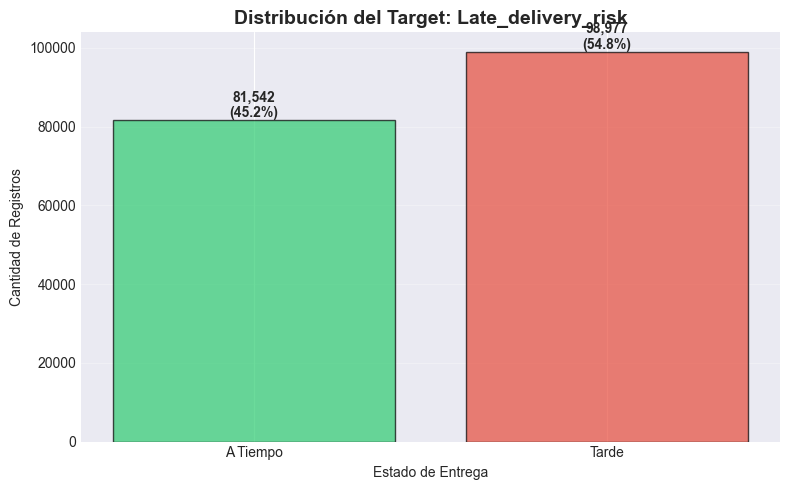

In [8]:
if 'Late_delivery_risk' in df.columns:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    
    counts = df['Late_delivery_risk'].value_counts().sort_index()
    labels = ['A Tiempo', 'Tarde']
    colors = ['#2ecc71', '#e74c3c']
    
    bars = ax.bar(labels, counts.values, color=colors, alpha=0.7, edgecolor='black')
    
    # Añadir valores sobre las barras
    for bar, count in zip(bars, counts.values):
        height = bar.get_height()
        pct = count / counts.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_title('Distribución del Target: Late_delivery_risk', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cantidad de Registros')
    ax.set_xlabel('Estado de Entrega')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 9. Análisis de Delivery Status

Distribución de los diferentes estados de entrega para identificar envíos cancelados.

=== DISTRIBUCIÓN DE DELIVERY STATUS ===

Distribución completa:
  Late delivery            :  98,977 (54.83%)
  Advance shipping         :  41,592 (23.04%)
  Shipping on time         :  32,196 (17.84%)
  Shipping canceled        :   7,754 ( 4.30%)


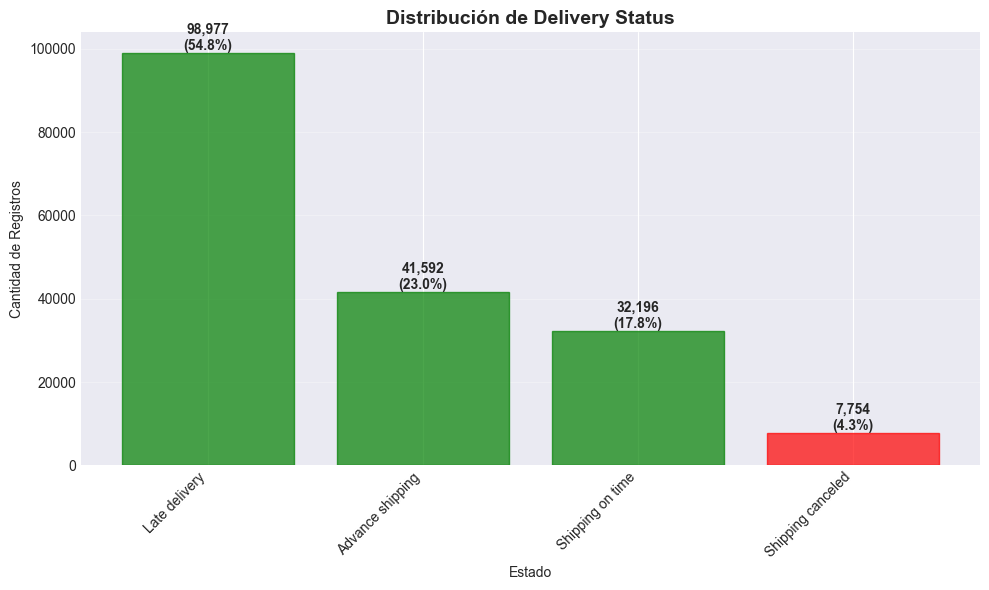


🔴 Envíos cancelados detectados: 7,754 (4.30%)


In [9]:
if 'Delivery_Status' in df.columns:
    print('=== DISTRIBUCIÓN DE DELIVERY STATUS ===\n')
    
    status_counts = df['Delivery_Status'].value_counts()
    status_pct = df['Delivery_Status'].value_counts(normalize=True) * 100
    
    print('Distribución completa:')
    for status in status_counts.index:
        print(f'  {status:25s}: {status_counts[status]:>7,} ({status_pct[status]:>5.2f}%)')
    
    # Visualización
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    bars = ax.bar(range(len(status_counts)), status_counts.values, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(status_counts)))
    ax.set_xticklabels(status_counts.index, rotation=45, ha='right')
    
    # Colorear según si se excluirá
    colors = ['red' if 'cancel' in str(s).lower() else 'green' for s in status_counts.index]
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    # Añadir valores
    for i, (count, pct) in enumerate(zip(status_counts.values, status_pct.values)):
        ax.text(i, count, f'{count:,}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_title('Distribución de Delivery Status', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cantidad de Registros')
    ax.set_xlabel('Estado')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Conteo de cancelados
    canceled = df[df['Delivery_Status'].str.contains('cancel', case=False, na=False)]
    print(f'\n🔴 Envíos cancelados detectados: {len(canceled):,} ({len(canceled)/len(df)*100:.2f}%)')
else:
    print('⚠️ Columna Delivery_Status no encontrada')

## 10. Tardanza por Shipping Mode

Análisis de `Late_delivery_risk` según el modo de envío.

=== TARDANZA POR SHIPPING MODE ===

Tasa de tardanza por modo de envío:


,Entregas_Tarde,Total_Entregas,Tasa_Tardanza
Shipping_Mode,,,
First Class,26513,27814,95.32
Second Class,26987,35216,76.63
Same Day,4454,9737,45.74
Standard Class,41023,107752,38.07


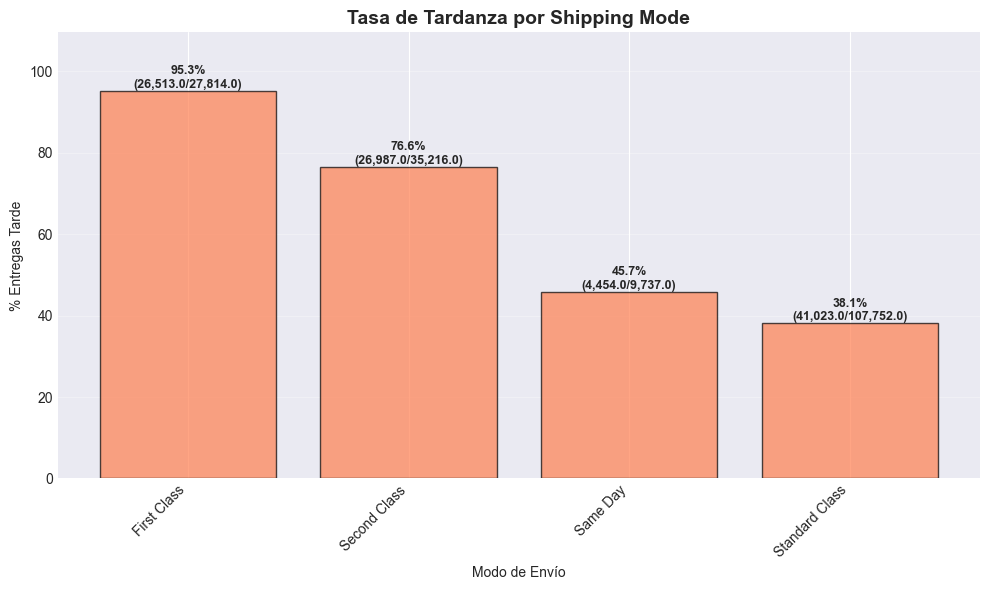

In [10]:
if 'Shipping_Mode' in df.columns and 'Late_delivery_risk' in df.columns:
    print('=== TARDANZA POR SHIPPING MODE ===\n')
    
    # Calcular tasa de tardanza por modo
    late_by_mode = df.groupby('Shipping_Mode')['Late_delivery_risk'].agg(['sum', 'count', 'mean'])
    late_by_mode.columns = ['Entregas_Tarde', 'Total_Entregas', 'Tasa_Tardanza']
    late_by_mode['Tasa_Tardanza'] = late_by_mode['Tasa_Tardanza'] * 100
    late_by_mode = late_by_mode.sort_values('Tasa_Tardanza', ascending=False)
    
    print('Tasa de tardanza por modo de envío:')
    display(late_by_mode)
    
    # Visualización
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    bars = ax.bar(range(len(late_by_mode)), late_by_mode['Tasa_Tardanza'], 
                   alpha=0.7, edgecolor='black', color='coral')
    ax.set_xticks(range(len(late_by_mode)))
    ax.set_xticklabels(late_by_mode.index, rotation=45, ha='right')
    
    # Añadir valores
    for i, (idx, row) in enumerate(late_by_mode.iterrows()):
        ax.text(i, row['Tasa_Tardanza'], 
                f'{row["Tasa_Tardanza"]:.1f}%\n({row["Entregas_Tarde"]:,}/{row["Total_Entregas"]:,})',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title('Tasa de Tardanza por Shipping Mode', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Entregas Tarde')
    ax.set_xlabel('Modo de Envío')
    ax.set_ylim(0, max(late_by_mode['Tasa_Tardanza']) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Columnas Shipping_Mode o Late_delivery_risk no encontradas')

## 11. Tardanza por Market y Order Region

Análisis de `Late_delivery_risk` por mercado y región de la orden.

=== TARDANZA POR MARKET ===



,Tarde,Total,Tasa
Market,,,
Europe,27743,50252,55.21
Pacific Asia,22712,41260,55.05
USCA,14138,25799,54.80
Africa,6340,11614,54.59
LATAM,28044,51594,54.36



=== TARDANZA POR ORDER REGION (Top 10) ===



,Tarde,Total,Tasa
Order_Region,,,
Central America,15518,28341,54.75
Western Europe,15140,27109,55.85
South America,8111,14935,54.31
Oceania,5482,10148,54.02
Northern Europe,5292,9792,54.04
Southeast Asia,5297,9539,55.53
Southern Europe,5129,9431,54.38
Caribbean,4415,8318,53.08
West of USA,4313,7993,53.96


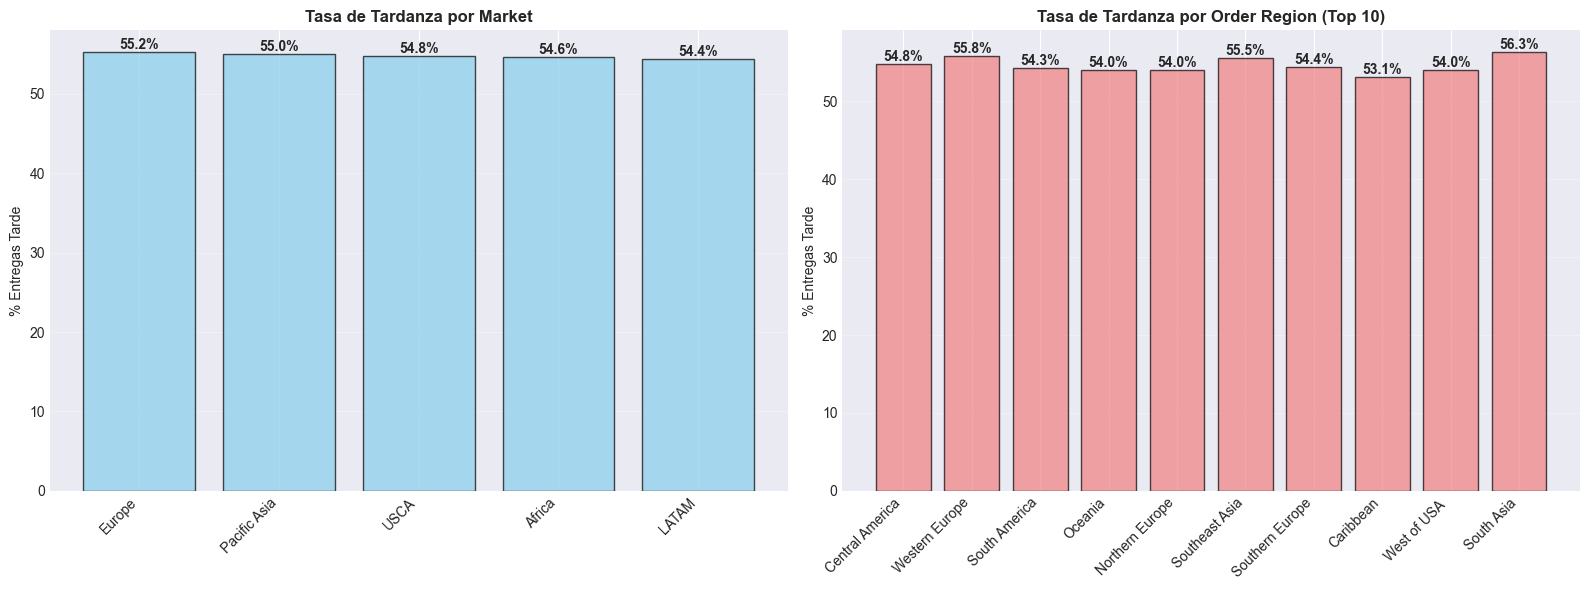

In [11]:
if 'Late_delivery_risk' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Por Market
    if 'Market' in df.columns:
        print('=== TARDANZA POR MARKET ===\n')
        late_by_market = df.groupby('Market')['Late_delivery_risk'].agg(['sum', 'count', 'mean'])
        late_by_market.columns = ['Tarde', 'Total', 'Tasa']
        late_by_market['Tasa'] = late_by_market['Tasa'] * 100
        late_by_market = late_by_market.sort_values('Tasa', ascending=False)
        
        display(late_by_market)
        
        # Gráfico
        bars = axes[0].bar(range(len(late_by_market)), late_by_market['Tasa'], 
                           alpha=0.7, edgecolor='black', color='skyblue')
        axes[0].set_xticks(range(len(late_by_market)))
        axes[0].set_xticklabels(late_by_market.index, rotation=45, ha='right')
        
        for i, (idx, row) in enumerate(late_by_market.iterrows()):
            axes[0].text(i, row['Tasa'], f'{row["Tasa"]:.1f}%', 
                        ha='center', va='bottom', fontweight='bold')
        
        axes[0].set_title('Tasa de Tardanza por Market', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('% Entregas Tarde')
        axes[0].grid(axis='y', alpha=0.3)
    
    # 2. Por Order Region (top 10)
    if 'Order_Region' in df.columns:
        print('\n=== TARDANZA POR ORDER REGION (Top 10) ===\n')
        late_by_region = df.groupby('Order_Region')['Late_delivery_risk'].agg(['sum', 'count', 'mean'])
        late_by_region.columns = ['Tarde', 'Total', 'Tasa']
        late_by_region['Tasa'] = late_by_region['Tasa'] * 100
        late_by_region = late_by_region.sort_values('Total', ascending=False).head(10)
        
        display(late_by_region)
        
        # Gráfico
        bars = axes[1].bar(range(len(late_by_region)), late_by_region['Tasa'], 
                           alpha=0.7, edgecolor='black', color='lightcoral')
        axes[1].set_xticks(range(len(late_by_region)))
        axes[1].set_xticklabels(late_by_region.index, rotation=45, ha='right')
        
        for i, (idx, row) in enumerate(late_by_region.iterrows()):
            axes[1].text(i, row['Tasa'], f'{row["Tasa"]:.1f}%', 
                        ha='center', va='bottom', fontweight='bold')
        
        axes[1].set_title('Tasa de Tardanza por Order Region (Top 10)', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('% Entregas Tarde')
        axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Columna Late_delivery_risk no encontrada')

## 12. Distribución de Days for Shipment (Scheduled)

Histograma y boxplot del tiempo programado de envío.

=== DISTRIBUCIÓN DE DAYS FOR SHIPMENT (SCHEDULED) ===

Estadísticas:
  Min: 0
  Max: 4
  Media: 2.93
  Mediana: 4
  Moda: 4


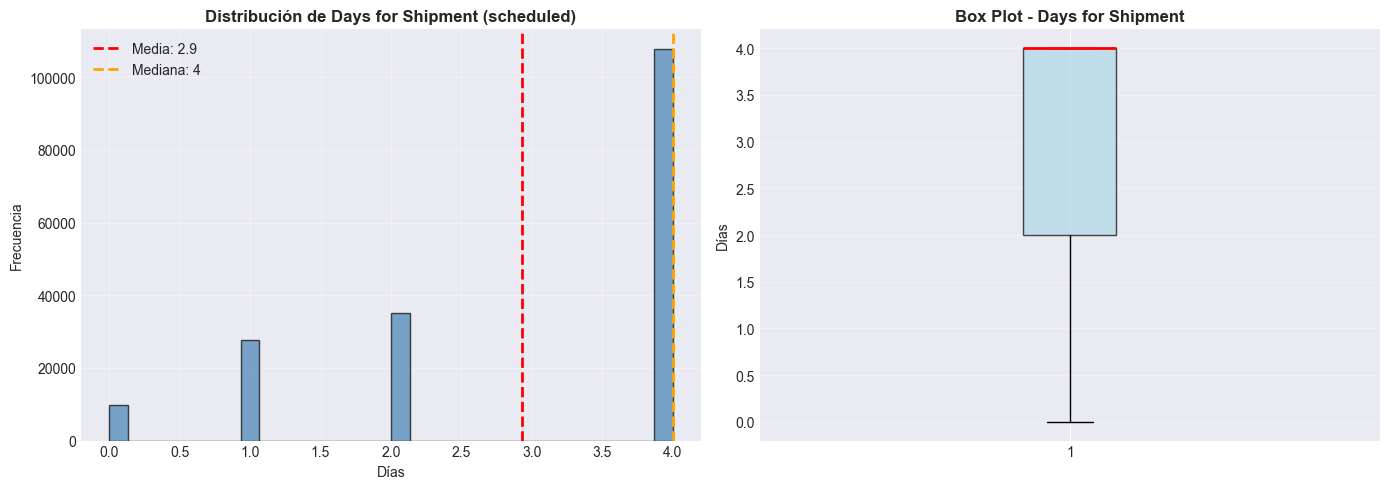

In [12]:
if 'Days_for_shipment_(scheduled)' in df.columns:
    print('=== DISTRIBUCIÓN DE DAYS FOR SHIPMENT (SCHEDULED) ===\n')
    
    days_col = df['Days_for_shipment_(scheduled)']
    
    print(f'Estadísticas:')
    print(f'  Min: {days_col.min()}')
    print(f'  Max: {days_col.max()}')
    print(f'  Media: {days_col.mean():.2f}')
    print(f'  Mediana: {days_col.median():.0f}')
    print(f'  Moda: {days_col.mode()[0] if len(days_col.mode()) > 0 else "N/A"}')
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(days_col.dropna(), bins=30, alpha=0.7, edgecolor='black', color='steelblue')
    axes[0].axvline(days_col.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {days_col.mean():.1f}')
    axes[0].axvline(days_col.median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {days_col.median():.0f}')
    axes[0].set_title('Distribución de Days for Shipment (scheduled)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Días')
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot
    axes[1].boxplot(days_col.dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('Box Plot - Days for Shipment', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Días')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Columna Days_for_shipment_(scheduled) no encontrada')

## 13. Feature Engineering: Processing Time

Creación de la variable `processing_time` (diferencia entre `shipping_date` y `order_date`).

=== CREACIÓN DE PROCESSING_TIME ===

✓ Variable processing_time creada

Estadísticas:
  Min: 0 días
  Max: 6 días
  Media: 3.47 días
  Mediana: 3.0 días
  Nulos: 0

Comparación por clase:
  A Tiempo (0): Media = 2.78 días
  Tarde (1):    Media = 4.04 días
  Diferencia:   1.27 días


C:\Users\joako\AppData\Local\Temp\ipykernel_30552\3867791953.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_class, labels=['A Tiempo', 'Tarde'],


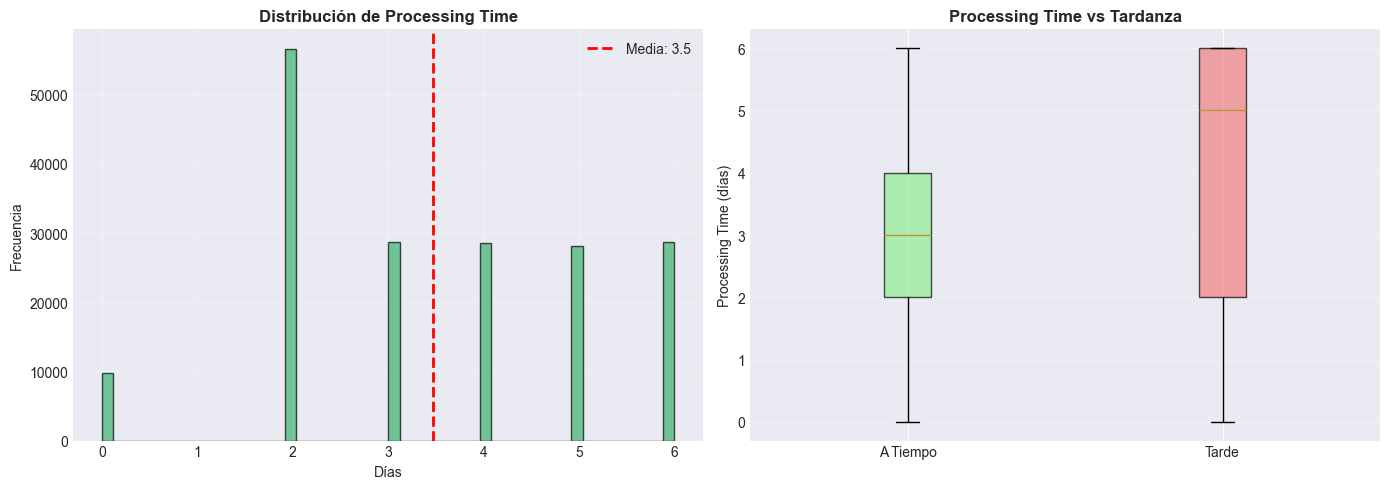

In [13]:
if 'order_date_(DateOrders)' in df.columns and 'shipping_date_(DateOrders)' in df.columns:
    print('=== CREACIÓN DE PROCESSING_TIME ===\n')
    
    # Crear variable processing_time (en días)
    df['processing_time'] = (df['shipping_date_(DateOrders)'] - df['order_date_(DateOrders)']).dt.days
    
    print(f'✓ Variable processing_time creada')
    print(f'\nEstadísticas:')
    print(f'  Min: {df["processing_time"].min()} días')
    print(f'  Max: {df["processing_time"].max()} días')
    print(f'  Media: {df["processing_time"].mean():.2f} días')
    print(f'  Mediana: {df["processing_time"].median():.1f} días')
    print(f'  Nulos: {df["processing_time"].isna().sum():,}')
    
    # Detectar valores negativos (inconsistencias)
    negativos = (df['processing_time'] < 0).sum()
    if negativos > 0:
        print(f'\n⚠️ ADVERTENCIA: {negativos:,} casos con processing_time negativo')
        print(f'   (shipping_date anterior a order_date - posible error de datos)')
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma general
    axes[0].hist(df['processing_time'].dropna(), bins=50, alpha=0.7, 
                 edgecolor='black', color='mediumseagreen')
    axes[0].axvline(df['processing_time'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Media: {df["processing_time"].mean():.1f}')
    axes[0].set_title('Distribución de Processing Time', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Días')
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot por clase de tardanza
    if 'Late_delivery_risk' in df.columns:
        data_by_class = [
            df[df['Late_delivery_risk'] == 0]['processing_time'].dropna(),
            df[df['Late_delivery_risk'] == 1]['processing_time'].dropna()
        ]
        
        bp = axes[1].boxplot(data_by_class, labels=['A Tiempo', 'Tarde'],
                             patch_artist=True, showfliers=False)
        
        # Colorear
        colors = ['lightgreen', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        axes[1].set_title('Processing Time vs Tardanza', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Processing Time (días)')
        axes[1].grid(axis='y', alpha=0.3)
        
        # Estadísticas comparativas
        print(f'\nComparación por clase:')
        print(f'  A Tiempo (0): Media = {data_by_class[0].mean():.2f} días')
        print(f'  Tarde (1):    Media = {data_by_class[1].mean():.2f} días')
        print(f'  Diferencia:   {data_by_class[1].mean() - data_by_class[0].mean():.2f} días')
    
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Columnas de fecha necesarias no encontradas')

## 14. Tendencia Temporal de Tardanza

Evolución mensual de la tasa de entregas tardías.

=== TENDENCIA TEMPORAL DE TARDANZA ===

Rango temporal: 2015-01-01 00:00:00 a 2018-02-01 00:00:00
Total meses: 38

Tasa promedio de tardanza: 55.08%


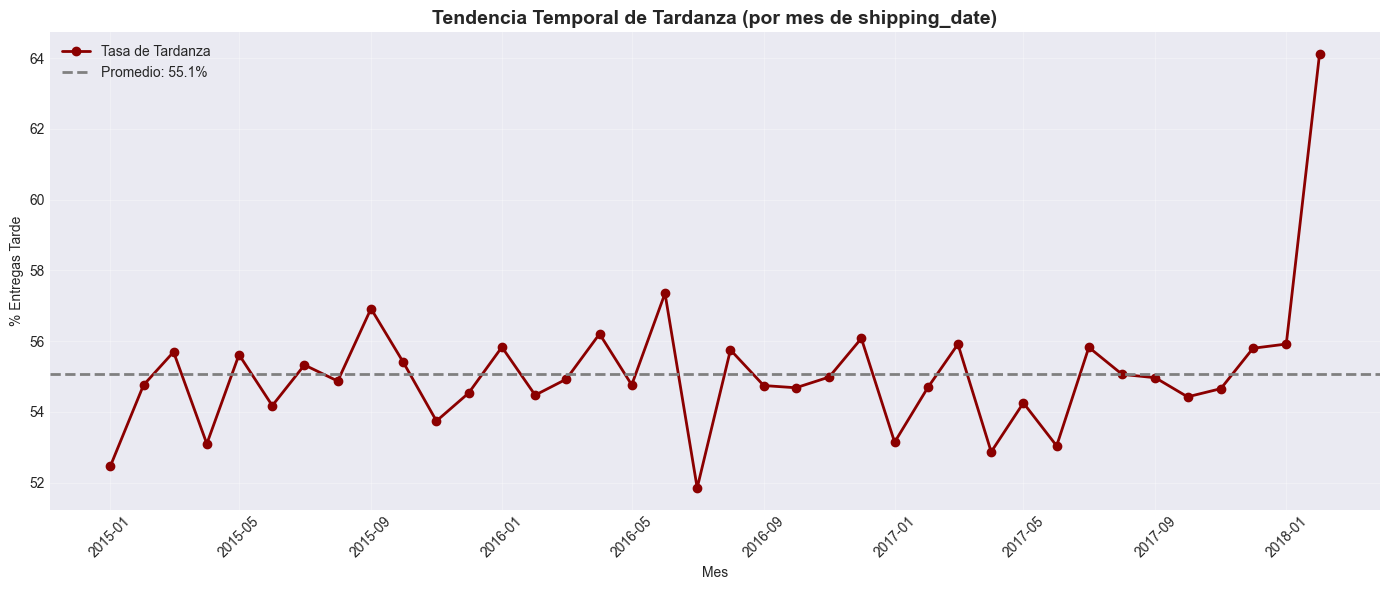


Primeros 5 meses:


,Tarde,Total,Tasa
year_month,,,
2015-01-01,2464,4697,52.46
2015-02-01,2619,4783,54.76
2015-03-01,2959,5313,55.69
2015-04-01,2726,5134,53.10
2015-05-01,2946,5297,55.62



Últimos 5 meses:


,Tarde,Total,Tasa
year_month,,,
2017-10-01,1433,2633,54.42
2017-11-01,1127,2062,54.66
2017-12-01,1179,2113,55.80
2018-01-01,1186,2121,55.92
2018-02-01,159,248,64.11


In [14]:
if 'shipping_date_(DateOrders)' in df.columns and 'Late_delivery_risk' in df.columns:
    print('=== TENDENCIA TEMPORAL DE TARDANZA ===\n')
    
    # Crear columna año-mes
    df_temp = df.copy()
    df_temp['year_month'] = df_temp['shipping_date_(DateOrders)'].dt.to_period('M')
    
    # Calcular tasa de tardanza mensual
    monthly_late = df_temp.groupby('year_month')['Late_delivery_risk'].agg(['sum', 'count', 'mean'])
    monthly_late.columns = ['Tarde', 'Total', 'Tasa']
    monthly_late['Tasa'] = monthly_late['Tasa'] * 100
    monthly_late.index = monthly_late.index.to_timestamp()
    
    print(f'Rango temporal: {monthly_late.index.min()} a {monthly_late.index.max()}')
    print(f'Total meses: {len(monthly_late)}')
    print(f'\nTasa promedio de tardanza: {monthly_late["Tasa"].mean():.2f}%')
    
    # Visualización
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    
    ax.plot(monthly_late.index, monthly_late['Tasa'], marker='o', 
            linewidth=2, markersize=6, color='darkred', label='Tasa de Tardanza')
    ax.axhline(monthly_late['Tasa'].mean(), color='gray', linestyle='--', 
               linewidth=2, label=f'Promedio: {monthly_late["Tasa"].mean():.1f}%')
    
    ax.set_title('Tendencia Temporal de Tardanza (por mes de shipping_date)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Mes')
    ax.set_ylabel('% Entregas Tarde')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Primeros y últimos meses
    print(f'\nPrimeros 5 meses:')
    display(monthly_late.head())
    print(f'\nÚltimos 5 meses:')
    display(monthly_late.tail())
else:
    print('⚠️ Columnas shipping_date_(DateOrders) o Late_delivery_risk no encontradas')

## 15. Análisis de Valores Nulos

Identificación de columnas con datos faltantes y sus porcentajes.

In [15]:
# Calcular porcentaje de nulos por columna
null_stats = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': df.isna().sum().values,
    'Porcentaje': (df.isna().sum().values / len(df) * 100)
}).sort_values('Nulos', ascending=False)

# Filtrar solo columnas con nulos
null_stats_filtered = null_stats[null_stats['Nulos'] > 0]

if len(null_stats_filtered) > 0:
    print(f'=== COLUMNAS CON VALORES NULOS (Total: {len(null_stats_filtered)}) ===')
    display(null_stats_filtered.head(20))
    
    # Resumen
    total_nulls = null_stats_filtered['Nulos'].sum()
    total_cells = df.shape[0] * df.shape[1]
    print(f'\nTotal de valores nulos: {total_nulls:,} ({total_nulls/total_cells*100:.2f}% del dataset)')
else:
    print('✓ No se encontraron valores nulos en el dataset')

=== COLUMNAS CON VALORES NULOS (Total: 4) ===


,Columna,Nulos,Porcentaje
46,Product_Description,180519,100.00
43,Order_Zipcode,155679,86.24
14,Customer_Lname,8,0.00
19,Customer_Zipcode,3,0.00



Total de valores nulos: 336,209 (3.45% del dataset)


## 16. Limpieza del Dataset

Eliminación de columnas irrelevantes/sensibles: IDs con alta cardinalidad, columnas constantes, columnas con >95% nulos, y columnas de información sensible que no aportan valor predictivo.

In [16]:
print('=== IDENTIFICACIÓN DE COLUMNAS A ELIMINAR ===\n')

cols_to_drop = []

# 1. Columnas con un solo valor (constantes)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
if constant_cols:
    cols_to_drop.extend(constant_cols)
    print(f'1. Columnas constantes ({len(constant_cols)}): {constant_cols}')

# 2. Columnas tipo ID con alta cardinalidad (>90% de unicidad)
id_patterns = ['id', 'key', 'code', 'number']
potential_ids = [col for col in df.columns 
                 if any(pattern in col.lower() for pattern in id_patterns)
                 and df[col].nunique() > len(df) * 0.9]
if potential_ids:
    cols_to_drop.extend(potential_ids)
    print(f'\n2. Columnas tipo ID (alta cardinalidad, >{len(df)*0.9:.0f} valores únicos):')  
    for col in potential_ids:
        print(f'   - {col}: {df[col].nunique():,} valores únicos')

# 3. Columnas con >95% de nulos
high_null_cols = df.columns[df.isna().mean() > 0.95].tolist()
if high_null_cols:
    cols_to_drop.extend(high_null_cols)
    print(f'\n3. Columnas con >95% nulos ({len(high_null_cols)}): {high_null_cols}')

# 4. Columnas duplicadas (mismo contenido)
duplicate_cols = []
for i, col1 in enumerate(df.columns):
    for col2 in df.columns[i+1:]:
        if df[col1].equals(df[col2]):
            duplicate_cols.append(col2)
if duplicate_cols:
    cols_to_drop.extend(duplicate_cols)
    print(f'\n4. Columnas duplicadas ({len(duplicate_cols)}): {duplicate_cols}')

# 5. Columnas de información sensible/inútil (definidas manualmente)
sensitive_cols = [
    'Customer_Email',
    'Customer_Password',
    'Customer_Fname',
    'Customer_Lname',
    'Customer_Full_Name',
    'Customer_Street',
    'Customer_Zipcode',
    'Order_Zipcode',
    'Latitude',
    'Longitude',
    'Product_Description',
    'Product_Image'
]
sensitive_found = [col for col in sensitive_cols if col in df.columns]
if sensitive_found:
    cols_to_drop.extend(sensitive_found)
    print(f'\n5. Columnas sensibles/inútiles ({len(sensitive_found)}): {sensitive_found}')

# Eliminar duplicados de la lista final
cols_to_drop = list(set(cols_to_drop))

print(f'\n' + '='*60)
print(f'RESUMEN:')
print(f'  Columnas originales: {df.shape[1]}')
print(f'  Columnas a eliminar: {len(cols_to_drop)}')
print(f'  Columnas resultantes: {df.shape[1] - len(cols_to_drop)}')
print('='*60)

if len(cols_to_drop) > 0:
    # Aplicar limpieza
    print(f'\nAplicando limpieza...')
    df_clean = df.drop(columns=cols_to_drop)
    print(f'✓ Dataset limpio: {df_clean.shape}')
else:
    print('\n✓ No hay columnas para eliminar')
    df_clean = df.copy()

=== IDENTIFICACIÓN DE COLUMNAS A ELIMINAR ===

1. Columnas constantes (4): ['Customer_Email', 'Customer_Password', 'Product_Description', 'Product_Status']

2. Columnas tipo ID (alta cardinalidad, >162467 valores únicos):
   - Order_Item_Id: 180,519 valores únicos

3. Columnas con >95% nulos (1): ['Product_Description']

4. Columnas duplicadas (7): ['Order_Profit_Per_Order', 'Order_Item_Total', 'Product_Category_Id', 'Customer_Password', 'Order_Customer_Id', 'Product_Card_Id', 'Product_Price']

5. Columnas sensibles/inútiles (11): ['Customer_Email', 'Customer_Password', 'Customer_Fname', 'Customer_Lname', 'Customer_Street', 'Customer_Zipcode', 'Order_Zipcode', 'Latitude', 'Longitude', 'Product_Description', 'Product_Image']

RESUMEN:
  Columnas originales: 54
  Columnas a eliminar: 19
  Columnas resultantes: 35

Aplicando limpieza...
✓ Dataset limpio: (180519, 35)


## 17. Resumen de Hallazgos

Síntesis de los principales descubrimientos del análisis exploratorio.

In [17]:
print('='*70)
print(' '*20 + 'RESUMEN DE HALLAZGOS')
print('='*70)

print('\n📊 DATASET ORIGINAL:')
print(f'   Filas: {len(df):,}')
print(f'   Columnas: {df.shape[1]}')

print('\n🎯 TARGET (Late_delivery_risk):')
if 'Late_delivery_risk' in df.columns:
    clase_0 = (df['Late_delivery_risk'] == 0).sum()
    clase_1 = (df['Late_delivery_risk'] == 1).sum()
    print(f'   Clase 0 (A tiempo): {clase_0:,} ({clase_0/len(df)*100:.2f}%)')
    print(f'   Clase 1 (Tarde):    {clase_1:,} ({clase_1/len(df)*100:.2f}%)')
    print(f'   Balance ratio: {min(clase_0, clase_1)/max(clase_0, clase_1):.3f}')

print('\n📅 FECHAS:')
if 'order_date_(DateOrders)' in df.columns:
    print(f'   Rango order_date: {df["order_date_(DateOrders)"].min().date()} a {df["order_date_(DateOrders)"].max().date()}')
if 'shipping_date_(DateOrders)' in df.columns:
    print(f'   Rango shipping_date: {df["shipping_date_(DateOrders)"].min().date()} a {df["shipping_date_(DateOrders)"].max().date()}')

print('\n🚚 DELIVERY STATUS:')
if 'Delivery_Status' in df.columns:
    for status, count in df['Delivery_Status'].value_counts().items():
        pct = count/len(df)*100
        print(f'   {status}: {count:,} ({pct:.2f}%)')

print('\n📦 SHIPPING MODE:')
if 'Shipping_Mode' in df.columns and 'Late_delivery_risk' in df.columns:
    mode_late = df.groupby('Shipping_Mode')['Late_delivery_risk'].mean() * 100
    for mode, rate in mode_late.sort_values(ascending=False).items():
        print(f'   {mode}: {rate:.1f}% tardanza')

print('\n🌎 GEOGRAFÍA:')
if 'Market' in df.columns:
    print(f'   Markets únicos: {df["Market"].nunique()}')
if 'Order_Region' in df.columns:
    print(f'   Regiones únicas: {df["Order_Region"].nunique()}')
if 'Order_Country' in df.columns:
    print(f'   Países únicos: {df["Order_Country"].nunique()}')

print('\n⏱️ PROCESSING TIME (feature creada):')
if 'processing_time' in df.columns:
    print(f'   Media: {df["processing_time"].mean():.2f} días')
    print(f'   Mediana: {df["processing_time"].median():.1f} días')
    if 'Late_delivery_risk' in df.columns:
        pt_ontime = df[df['Late_delivery_risk']==0]['processing_time'].mean()
        pt_late = df[df['Late_delivery_risk']==1]['processing_time'].mean()
        print(f'   A tiempo: {pt_ontime:.2f} días')
        print(f'   Tarde: {pt_late:.2f} días')
        print(f'   Diferencia: {pt_late - pt_ontime:.2f} días')

print('\n🧹 LIMPIEZA APLICADA:')
print(f'   Columnas eliminadas: {len(cols_to_drop) if "cols_to_drop" in locals() else 0}')
print(f'   Dataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')

print('\n🔍 CALIDAD DE DATOS:')
null_count = df_clean.isna().sum().sum()
dup_count = df_clean.duplicated().sum()
print(f'   Valores nulos: {null_count:,}')
print(f'   Filas duplicadas: {dup_count:,}')

print('\n' + '='*70)
print(' '*15 + '✅ ANÁLISIS EXPLORATORIO COMPLETADO')
print('='*70)

                    RESUMEN DE HALLAZGOS

📊 DATASET ORIGINAL:
   Filas: 180,519
   Columnas: 54

🎯 TARGET (Late_delivery_risk):
   Clase 0 (A tiempo): 81,542 (45.17%)
   Clase 1 (Tarde):    98,977 (54.83%)
   Balance ratio: 0.824

📅 FECHAS:
   Rango order_date: 2015-01-01 a 2018-01-31
   Rango shipping_date: 2015-01-03 a 2018-02-06

🚚 DELIVERY STATUS:
   Late delivery: 98,977 (54.83%)
   Advance shipping: 41,592 (23.04%)
   Shipping on time: 32,196 (17.84%)
   Shipping canceled: 7,754 (4.30%)

📦 SHIPPING MODE:
   First Class: 95.3% tardanza
   Second Class: 76.6% tardanza
   Same Day: 45.7% tardanza
   Standard Class: 38.1% tardanza

🌎 GEOGRAFÍA:
   Markets únicos: 5
   Regiones únicas: 23
   Países únicos: 164

⏱️ PROCESSING TIME (feature creada):
   Media: 3.47 días
   Mediana: 3.0 días
   A tiempo: 2.78 días
   Tarde: 4.04 días
   Diferencia: 1.27 días

🧹 LIMPIEZA APLICADA:
   Columnas eliminadas: 19
   Dataset limpio: 180,519 filas × 35 columnas

🔍 CALIDAD DE DATOS:
   Valores nulo

## 18. Guardar Dataset Limpio

Exportación del dataset limpio a CSV para análisis posteriores.

In [ ]:
# Crear directorio de salida si no existe
output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Guardar dataset limpio
output_path = output_dir / 'DataCoSupplyChainDataset_clean.csv'
df_clean.to_csv(output_path, index=False)

print('='*60)
print(f'✓ Dataset limpio guardado: {output_path}')
print(f'  Tamaño: {output_path.stat().st_size / 1024 / 1024:.2f} MB')
print(f'  Filas: {df_clean.shape[0]:,}')
print(f'  Columnas: {df_clean.shape[1]}')
print('='*60)

✓ Dataset limpio guardado: ..\data\processed\DataCoSupplyChainDataset_clean.csv
  Tamaño: 57.43 MB
  Filas: 180,519
  Columnas: 35


In [ ]:
df.columns